## What is AQI?
AQI (Air Quality Index) is a single number that represents how polluted the air is and how it affects human health.

### Instead of showing many pollutants separately (PM2.5, PM10, CO, NO2, etc.), AQI:
Converts pollutant values into sub-indices

Takes the worst (maximum) sub-index

Reports it as the AQI of that area
## Why AQI Analysis is Important
Helps government issue health warnings

Helps citizens decide outdoor activities

Helps researchers study pollution trends

## STEP 1: Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Why are we using these?
pandas → For reading, cleaning, and analyzing data

matplotlib → For visualization (graphs & trends)

## STEP 2: Load the Dataset

In [2]:
df=pd.read_csv("delhiaqi.csv")

### What this does:

Reads the CSV file

Stores it as a DataFrame (table-like structure)

### Always Check Your Data

In [3]:
df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


Why?

1. Confirms data loaded correctly
2. Shows column names and sample values

## STEP 3: Data Cleaning & Preprocessing
### 3.1 Convert Date Column

In [4]:
df['date'] = pd.to_datetime(df['date'])

Why?

. Date is initially a string
   
. Converting allows:

1. Time-based analysis
2. Monthly/daily trends

### 3.2 Check Missing Values

In [5]:
df.isnull().sum()

date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

***dataset has no missing values.***

## STEP 4: Overall pollution severity

### Average pollutant levels

In [6]:
pollutants = ["pm2_5", "pm10", "no2", "so2", "co", "o3"]
df[pollutants].describe()

,pm2_5,pm10,no2,so2,co,o3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,358.256364,420.988414,75.292496,64.655936,3814.942210,30.141943
std,227.359117,271.287026,42.473791,61.073080,3227.744681,39.979405
min,60.100000,69.080000,13.370000,5.250000,654.220000,0.000000
25%,204.450000,240.900000,44.550000,28.130000,1708.980000,0.070000
50%,301.170000,340.900000,63.750000,47.210000,2590.180000,11.800000
75%,416.650000,482.570000,97.330000,77.250000,4432.680000,47.210000
max,1310.200000,1499.270000,263.210000,511.170000,16876.220000,164.510000


#### Which pollutants are worst?

**Mean comparison**

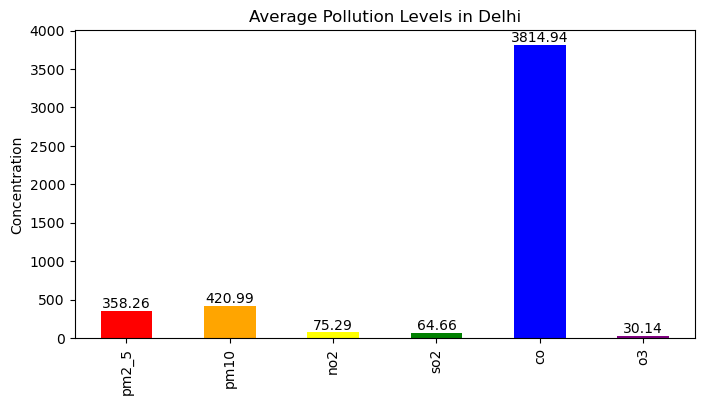

In [7]:
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

ax = df[pollutants].mean().plot(
    kind='bar',
    figsize=(8,4),
    color=colors)
plt.title("Average Pollution Levels in Delhi")
plt.ylabel("Concentration")
# Add data labels on each bar--->
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.show()

***Seasonal analysis***

***Create seasons:***

In [8]:
df["month"] = df["date"].dt.month

def get_season(m):
    if m in [12,1,2]:
        return "Winter"
    elif m in [3,4,5]:
        return "Summer"
    elif m in [6,7,8,9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["season"] = df["month"].apply(get_season)
print(df["season"])

0      Winter
1      Winter
2      Winter
3      Winter
4      Winter
        ...  
556    Winter
557    Winter
558    Winter
559    Winter
560    Winter
Name: season, Length: 561, dtype: object


## STEP 5:Seasonal pollutant trend

In [9]:
df.groupby("season")[pollutants].mean()

,pm2_5,pm10,no2,so2,co,o3
season,,,,,,
Winter,358.256364,420.988414,75.292496,64.655936,3814.94221,30.141943


## STEP 6: Visualization:

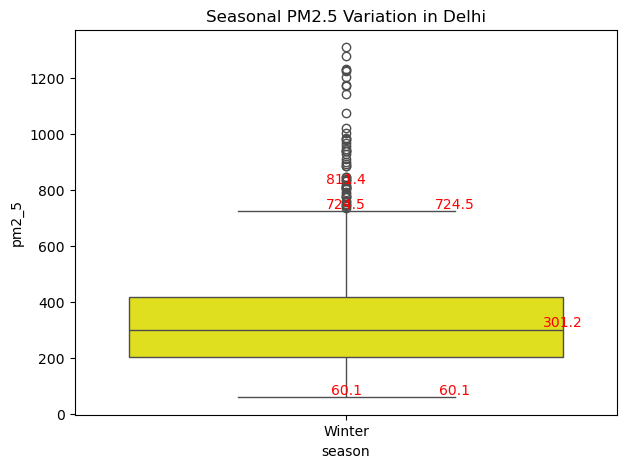

In [21]:
plt.figure(figsize=(7,5))
ax=sns.boxplot(x="season", y="pm2_5", data=df,color="yellow")

## add median levels :
for line in ax.lines:
    x,y=line.get_xydata()[1]
    ax.text(x,y,f'{y:.1f}',ha="center",
           va="bottom",color="red")
plt.title("Seasonal PM2.5 Variation in Delhi")
plt.show()

## STEP 7:Correlation between pollutants

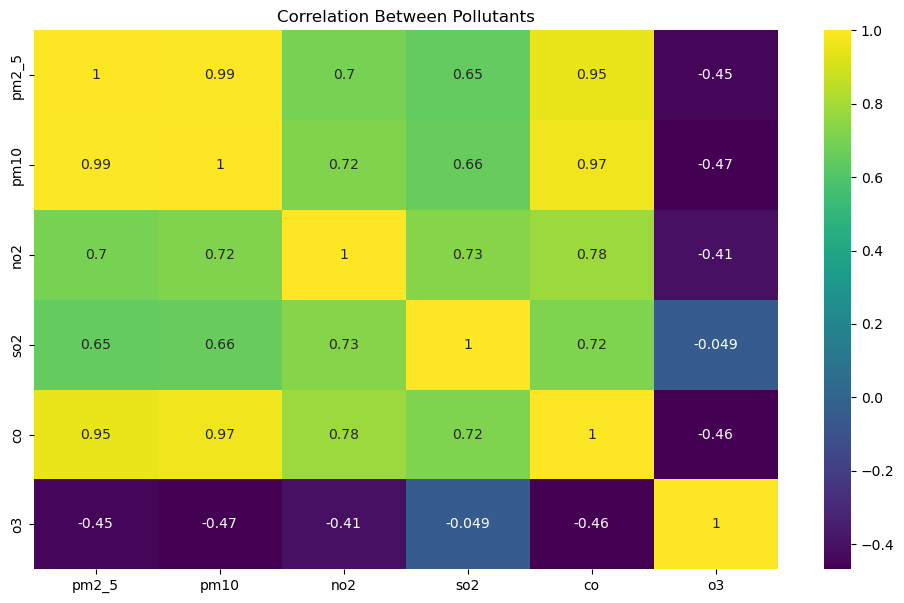

In [11]:
corr = df[pollutants].corr()

plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, cmap="viridis")
plt.title("Correlation Between Pollutants")
plt.show()

### the maximum PM2.5 value

In [12]:
df["pm2_5"].max()

1310.2

### the date for it

In [13]:
df.loc[df["pm2_5"].idxmax(), ["date", "pm2_5"]]

date     2023-01-19 17:00:00
pm2_5                 1310.2
Name: 449, dtype: object

### Date with highest PM10

In [14]:
df.loc[df["pm10"].idxmax(), ["date", "pm10"]]

date    2023-01-19 17:00:00
pm10                1499.27
Name: 449, dtype: object

### Date with highest value for EACH pollutant

In [15]:
for p in pollutants:
    print(p)
    print(df.loc[df[p].idxmax(), ["date", p]])
    print("------")

pm2_5
date     2023-01-19 17:00:00
pm2_5                 1310.2
Name: 449, dtype: object
------
pm10
date    2023-01-19 17:00:00
pm10                1499.27
Name: 449, dtype: object
------
no2
date    2023-01-19 16:00:00
no2                  263.21
Name: 448, dtype: object
------
so2
date    2023-01-19 17:00:00
so2                  511.17
Name: 449, dtype: object
------
co
date    2023-01-13 17:00:00
co                 16876.22
Name: 305, dtype: object
------
o3
date    2023-01-17 09:00:00
o3                   164.51
Name: 393, dtype: object
------


### Overall most polluted day
#### Create pollution load

In [16]:
df["Total_Pollution"] = df[pollutants].sum(axis=1)
print(df["Total_Pollution"])

0      2082.70
1      2329.44
2      3064.93
3      3789.12
4      4150.32
        ...   
556    2384.17
557    2357.07
558    2601.17
559    1943.79
560    1646.52
Name: Total_Pollution, Length: 561, dtype: float64


### Find worst day

In [17]:
df.loc[df["Total_Pollution"].idxmax(), ["date", "Total_Pollution"]]

date               2023-01-19 17:00:00
Total_Pollution               20235.49
Name: 449, dtype: object

### Visualize pollution over time

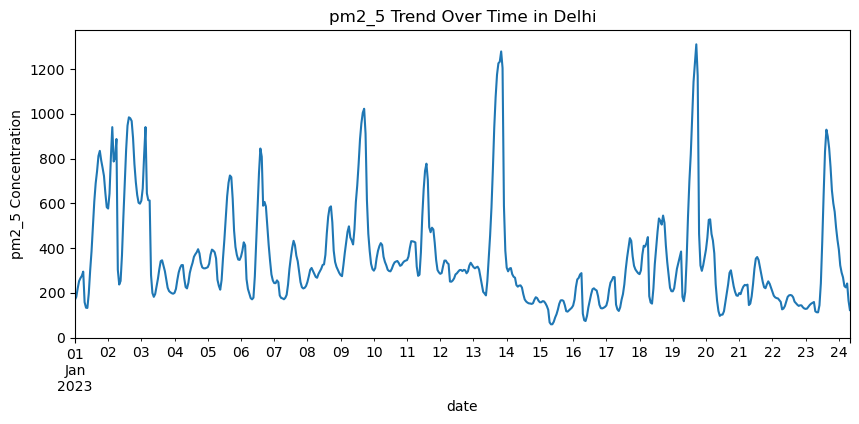

In [18]:
df.set_index("date")["pm2_5"].plot(figsize=(10,4))
plt.title("pm2_5 Trend Over Time in Delhi")
plt.ylabel("pm2_5 Concentration")
plt.show()

Second video:***<a href="https://www.loom.com/share/8115ee1427bc4f588b7f7727f5f3c449">presentation video no. II </a>***